# 15 · In-season yield forecast

Compare wheat yield forecasts on two dates using historical weather to represent the rest of the 2020 season.

## You will learn

- Run a copied forecast FileX with a chosen forecast date.
- Read one grain-yield result per historical weather year.
- Compare forecast distributions as more current-season weather becomes available.

In [1]:
LESSON = "15_yield_forecast"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load tools for tables and inline plots.

In [3]:
# Load the lesson tools.
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready: tables and plots.")

Tools ready: tables and plots.


Preview the stock FileX treatments and weather record before selecting treatment 1.

In [4]:
# Select the copied inputs and preview the stock forecast dates.
inputs = {
    "filex": RUNS / "CAPE2002.FCX",
    "weather": RUNS / "CAPE8437.WTH",
    "soil": RUNS / "KZ.SOL",
    "executable": dssat,
}
print("Inputs:", ", ".join(inputs[key].relative_to(HERE).as_posix()
                          for key in ("filex", "weather", "soil")))
lines = inputs["filex"].read_text(encoding="utf-8").splitlines()
start = next(i for i, line in enumerate(lines) if line.startswith("*TREATMENTS"))
end = next(i for i in range(start + 1, len(lines)) if lines[i].startswith("*"))
print("\n".join(lines[start:end]).rstrip())
weather_lines = inputs["weather"].read_text(encoding="utf-8").splitlines()
dates = [line.split()[0] for line in weather_lines if line[:5].isdigit()]
print("Weather dates (YYDDD):", dates[0], "to", dates[-1])

Inputs: runs/CAPE2002.FCX, runs/CAPE8437.WTH, runs/KZ.SOL
*TREATMENTS                        -------------FACTOR LEVELS------------
@N R O C TNAME.................... CU FL SA IC MP MI MF MR MC MT ME MH SM
 1 1 1 0 WH forecast Jun 1, 2020    1  1  0  1  1  0  0  0  0  0  0  0  1
 2 1 1 0 WH forecast Jul 1, 2020    1  1  0  1  1  0  0  0  0  0  0  0  2
 3 1 1 0 WH forecast Aug 1, 2020    1  1  0  1  1  0  0  0  0  0  0  0  3
Weather dates (YYDDD): 84001 to 20229


🌱 Crop idea  
This stock case is a hypothetical wheat field near Petropavl, Kazakhstan, with cultivar North KAZAK1 and soil profile `KZ01826030`.
The stock weather header identifies NASA POWER data for 1984–2020; the file ends on 16 August 2020, so we use forecasts before that date.
The stock treatment retains automatic planting and irrigation, with water and nitrogen simulation enabled.

Check a June 1 forecast using treatment 1 and the stock 36-year history.

🐍 Python idea  
The `inputs` dictionary stores the file paths and DSSAT executable; `**inputs` passes these settings to `Simulation` as named arguments.

In [5]:
# Set the forecast date through public controls and check the inputs.
early_date = "2020-06-01"
history_years = 36
early_sim = dl.Simulation(
    **inputs, treatment=1,
    management={"treatments": {1: {"controls": {
        "forecast_date": early_date, "years": history_years,
    }}}},
)
problems = early_sim.check(verbose=False)
print("Problems:", problems)

Problems: []


🌱 Crop idea  
The forecast date is the first day taken from historical weather; before it, all members use the same current-season weather.
`years=36` uses 1984–2019 weather for the remaining season, yielding 36 possible outcomes for the same 2020 crop.

Run the June 1 forecast and preview grain yield (`HWAM`, kg/ha) and maturity date (`MDAT`).

In [6]:
# Run the early forecast and label the historical weather years in order.
early_result = early_sim.run()
early = dl.to_dataframe(dl.read_summary(early_result.run_dir))
early.insert(0, "Historical weather year", range(2020 - history_years, 2020))
early[["Historical weather year", "TRNO", "PDAT", "HWAM", "MDAT"]].head(6)

,Historical weather year,TRNO,PDAT,HWAM,MDAT
0,1984,1,2020-05-14,1114,2020-08-12
1,1985,1,2020-05-14,955,2020-08-18
2,1986,1,2020-05-14,1005,2020-08-21
3,1987,1,2020-05-14,1131,2020-08-09
4,1988,1,2020-05-14,1103,2020-08-09
5,1989,1,2020-05-14,1262,2020-08-05


🐍 Python idea  
`read_summary()` returns rows and `to_dataframe()` makes a table; `head(6)` displays its first six rows.
Historical weather years are assigned in the order documented by the [forecast guide](../../docs/guide/simulation.md#forecast-with-your-weather-data); maturity dates still belong to the forecast crop.

Run an August 1 forecast of the same treatment, changing only the forecast date.

In [7]:
# Run the later forecast using the same treatment and historical years.
late_date = "2020-08-01"
late_sim = dl.Simulation(
    **inputs, treatment=1,
    management={"treatments": {1: {"controls": {
        "forecast_date": late_date, "years": history_years,
    }}}},
)
late_result = late_sim.run()
late = dl.to_dataframe(dl.read_summary(late_result.run_dir))
late.insert(0, "Historical weather year", range(2020 - history_years, 2020))
late[["Historical weather year", "TRNO", "PDAT", "HWAM", "MDAT"]].head(6)

,Historical weather year,TRNO,PDAT,HWAM,MDAT
0,1984,1,2020-05-14,1322,2020-08-16
1,1985,1,2020-05-14,1322,2020-08-17
2,1986,1,2020-05-14,1295,2020-08-19
3,1987,1,2020-05-14,1322,2020-08-15
4,1988,1,2020-05-14,1322,2020-08-17
5,1989,1,2020-05-14,1322,2020-08-16


🌱 Crop idea  
Several August 1 members return exactly 1,322 kg/ha, which can look surprising.
Their mid-August maturity dates and longer shared current-season weather are consistent with little remaining weather influence, but these outputs do not establish the cause of the repeated yield.

Compare the mean, full range and central 80% yield interval at the two dates.

In [8]:
# Summarize the two forecast yield distributions in kg/ha.
statistics = []
for forecast_date, table in ((early_date, early), (late_date, late)):
    yields = table["HWAM"]
    statistics.append({
        "Forecast date": forecast_date,
        "Members": yields.count(),
        "Mean (kg/ha)": yields.mean(),
        "Minimum (kg/ha)": yields.min(),
        "P10 (kg/ha)": yields.quantile(0.10),
        "Median (kg/ha)": yields.median(),
        "P90 (kg/ha)": yields.quantile(0.90),
        "Maximum (kg/ha)": yields.max(),
        "P90 - P10 (kg/ha)": yields.quantile(0.90) - yields.quantile(0.10),
    })
forecast_summary = dl.to_dataframe(statistics).set_index("Forecast date")
forecast_summary.round(1)

,Members,Mean (kg/ha),Minimum (kg/ha),P10 (kg/ha),Median (kg/ha),P90 (kg/ha),Maximum (kg/ha),P90 - P10 (kg/ha)
Forecast date,,,,,,,,
2020-06-01,36,1076.9,669,821.5,1044.0,1332.0,1576,510.5
2020-08-01,36,1315.7,1281,1294.0,1322.0,1322.0,1322,28.0


🌱 Crop idea  
The central 80% spread narrows from 510.5 kg/ha on June 1 to 28.0 kg/ha on August 1, while the mean rises from 1,076.9 to 1,315.7 kg/ha.
P10 and P90 are the 10th and 90th percentiles; this spread describes these historical-weather outcomes, rather than all possible forecast errors.

Plot both yield distributions on the same bins and axes to compare their spread.

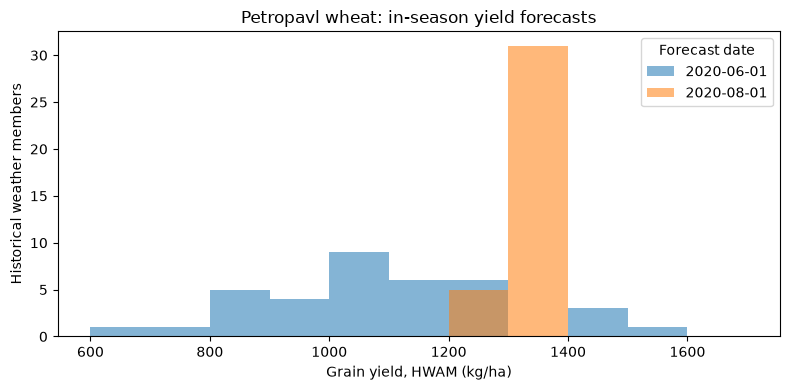

In [9]:
# Plot the two forecast distributions with shared 100 kg/ha bins.
lower = int(min(early["HWAM"].min(), late["HWAM"].min()) // 100) * 100
upper = int(max(early["HWAM"].max(), late["HWAM"].max()) // 100 + 2) * 100
bins = range(lower, upper + 1, 100)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(early["HWAM"], bins=bins, alpha=0.55, label=early_date)
ax.hist(late["HWAM"], bins=bins, alpha=0.55, label=late_date)
ax.set(xlabel="Grain yield, HWAM (kg/ha)", ylabel="Historical weather members",
       title="Petropavl wheat: in-season yield forecasts")
ax.legend(title="Forecast date")
plt.tight_layout()
plt.show()

Locate each run directory and its Summary file for inspecting the complete results.

In [10]:
# Show the relative run directories and collected Summary file names.
for forecast_date, result in ((early_date, early_result), (late_date, late_result)):
    names = [path.name for path in result.outputs if path.suffix.upper() == ".OSU"
             or path.name.upper() == "SUMMARY.OUT"]
    print(f"{forecast_date}: exit {result.returncode}; "
          f"{result.run_dir.relative_to(HERE).as_posix()}; " + ", ".join(names))

2020-06-01: exit 0; runs/dssat_sim_2026-10-06_203915/dssat_run_2026-10-06_203915; CAPE2002.OSU
2020-08-01: exit 0; runs/dssat_sim_2026-10-06_203921/dssat_run_2026-10-06_203921; CAPE2002.OSU


## Your turn

Run a forecast for a date between June 1 and August 1 and inspect its yield spread.

Hint: edit `chosen_date` (start with `"2020-07-01"`), then run this cell.

In [11]:
# Rebuild a forecast for the chosen date and show its yield distribution.
chosen_date = "2020-07-01"
exercise_sim = dl.Simulation(
    filex=RUNS / "CAPE2002.FCX", treatment=1,
    weather=RUNS / "CAPE8437.WTH", soil=RUNS / "KZ.SOL", executable=dssat,
    management={"treatments": {1: {"controls": {
        "forecast_date": chosen_date, "years": 36,
    }}}},
)
exercise_result = exercise_sim.run()
exercise = dl.to_dataframe(dl.read_summary(exercise_result.run_dir))
yields = exercise["HWAM"]
dl.to_dataframe([{
    "Forecast date": chosen_date,
    "Members": yields.count(),
    "Mean (kg/ha)": round(yields.mean(), 1),
    "P10 (kg/ha)": round(yields.quantile(0.10), 1),
    "P90 (kg/ha)": round(yields.quantile(0.90), 1),
    "P90 - P10 (kg/ha)": round(yields.quantile(0.90) - yields.quantile(0.10), 1),
}])

,Forecast date,Members,Mean (kg/ha),P10 (kg/ha),P90 (kg/ha),P90 - P10 (kg/ha)
0,2020-07-01,36,1227.7,1131.5,1339.5,208.0


## Recap

- A copied `.FCX` selects forecast mode Y; public controls change the forecast date in its simulation copy.
- Each Summary row uses one historical weather year for the remaining season; `HWAM` is grain yield in kg/ha.
- Tables and inline histograms compare the distribution as more of the current season becomes known.

You have reached the final lesson; next, revisit [13 · Seasonal analysis and economics](../13_seasonal_economics/lesson.ipynb) to compare whole seasons with in-season forecasts.